<a href="https://colab.research.google.com/github/nailahafizha/NyiurNaggroe/blob/main/03_ConvNeXt_Tiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. ConvNeXt Tiny
1. Import Library
2. Mount Drive & Import Pipeline
3. Validasi Pipeline
4. Konfigurasi Training & Output Directory
5. Membangun Model ConvNeXt Tiny
6. Loss, Optimizer, AMP Scaler
7. Fungsi Training (`train_one_epoch`, `validate`, `fit`)
8. Menjalankan Training
9. Visualisasi Training History
10. Evaluasi Model Terbaik (Macro F1, Classification Report, Confusion Matrix)
11. Prediksi Test Set & Submission File


## 1. Import Library

In [ ]:
# ==========================================================
# Standard Library
# ==========================================================

import os
import copy
import time

# ==========================================================
# Data Processing
# ==========================================================

import numpy as np
import pandas as pd

# ==========================================================
# Visualization
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# PyTorch
# ==========================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

# ==========================================================
# Metrics
# ==========================================================

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ==========================================================
# Progress Bar
# ==========================================================

from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore")


## 2. Mount Google Drive & Import Pipeline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import sys

PROJECT_DIR = "/content/drive/MyDrive/BDC2026"

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

print(f"PROJECT_DIR ditambahkan ke sys.path: {PROJECT_DIR}")


PROJECT_DIR ditambahkan ke sys.path: /content/drive/MyDrive/BDC2026


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Random seed initialized.
[OK] Project      : /content/drive/MyDrive/BDC2026
[OK] Dataset      : /content/drive/MyDrive/BDC2026/datasets
[OK] Train        : /content/drive/MyDrive/BDC2026/datasets/train
[OK] Test         : /content/drive/MyDrive/BDC2026/datasets/test
[OK] Model        : /content/drive/MyDrive/BDC2026/saved_models
[OK] Result       : /content/drive/MyDrive/BDC2026/results
[OK] Submission   : /content/drive/MyDrive/BDC2026/submission
Class Folder
1. 0_Recyclable
2. 1_Electronic
3. 2_Organic


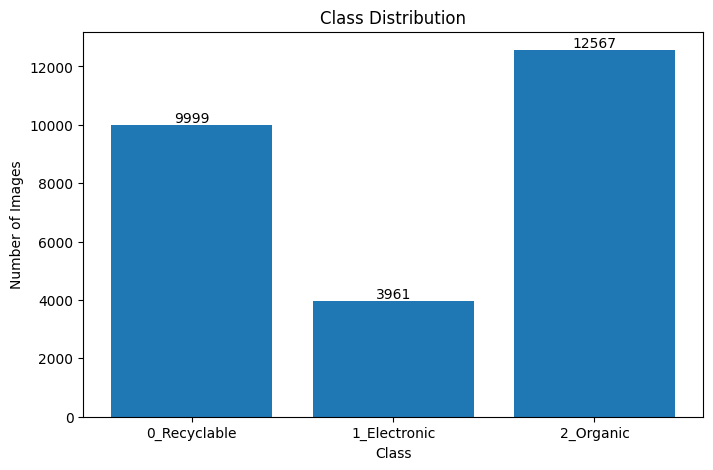

DATASET SUMMARY
Total Class     : 3
Total Images    : 26,527
Image Size      : 224 x 224
Batch Size      : 32
Device          : cuda
DATASET INFORMATION
Total Images : 26527
Total Classes: 3
Classes      : ['0_Recyclable', '1_Electronic', '2_Organic']


,Class,Index
0,0_Recyclable,0
1,1_Electronic,1
2,2_Organic,2


Train : 21221
Validation : 5306


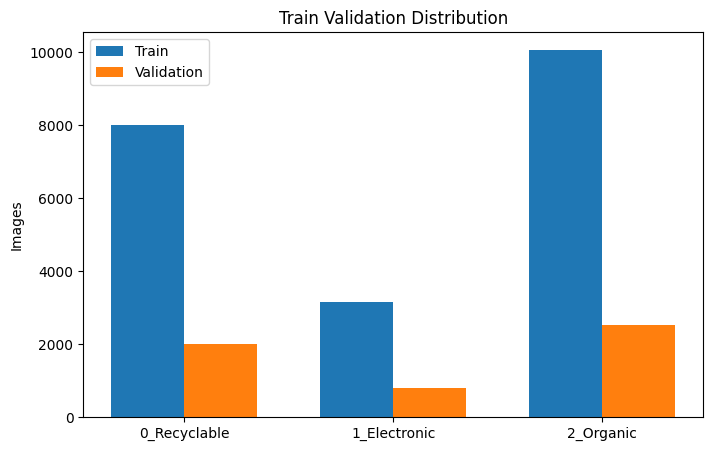

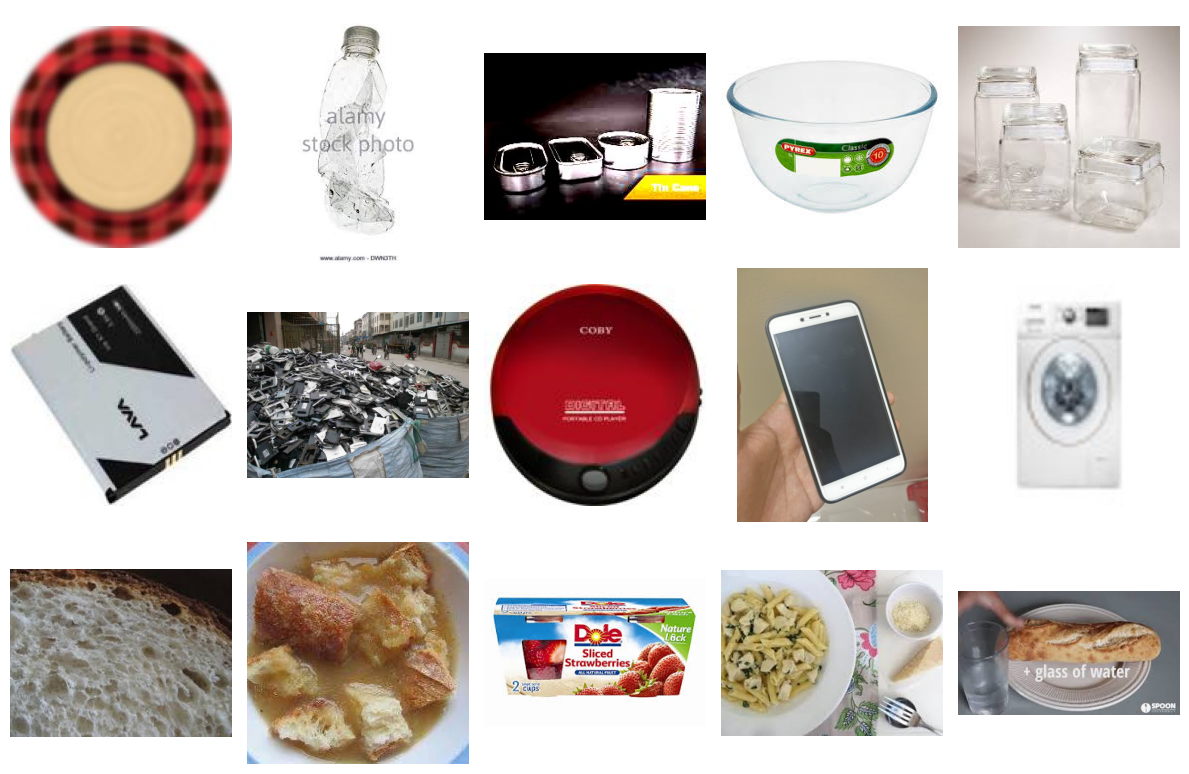

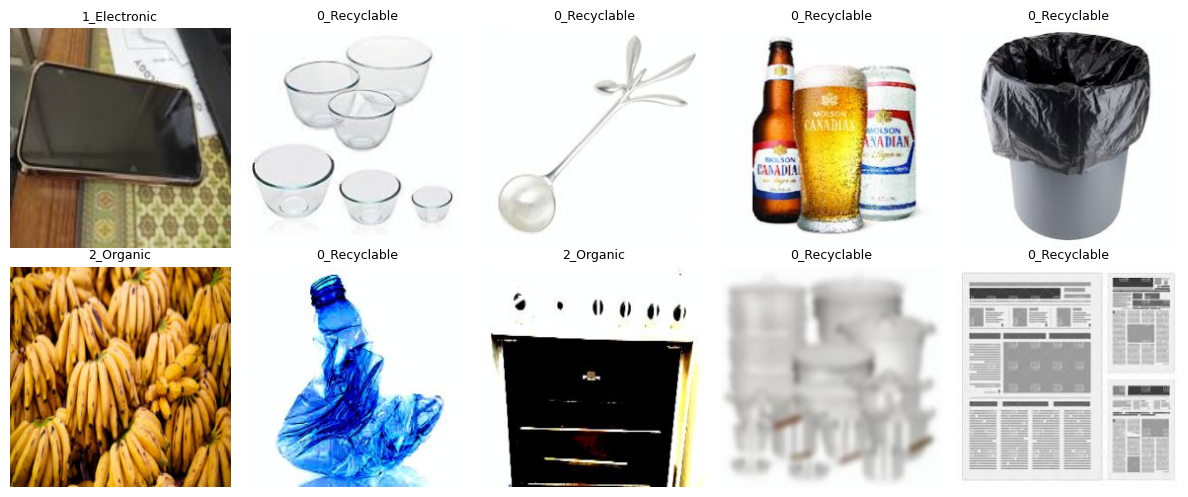

Total Test Images : 1458
TRAIN BATCH
Image Shape : torch.Size([32, 3, 224, 224])
Label Shape : torch.Size([32])
Image dtype : torch.float32
Label dtype : torch.int64
VALIDATION BATCH
torch.Size([32, 3, 224, 224])
torch.Size([32])
TEST BATCH
torch.Size([32, 3, 224, 224])
('1.jpg', '10.jpg', '100.jpg', '1000.jpg', '1001.jpg')
PIPELINE SUMMARY
Train Images      : 21,221
Validation Images : 5,306
Test Images       : 1,458
Batch Size        : 32
Image Size        : 224
Device            : cuda
PIPELINE READY
Train Dataset : 21221
Validation    : 5306
Test          : 1458

Number of Classes : 3

Ready for
- ResNet50
- EfficientNetB0
- ConvNeXt Tiny
- DenseNet121
- MobileNetV3
PIPELINE BERHASIL DI-IMPORT
Class Names   : ['0_Recyclable', '1_Electronic', '2_Organic']
Num Classes   : 3
Device        : cuda


In [ ]:
# ==========================================================
# Import objek pipeline dari pipeline_bdc.py
# ==========================================================

from pipeline_bdc import (
    train_loader,
    val_loader,
    test_loader,
    train_dataset,
    val_dataset,
    test_dataset,
    class_names,
    NUM_CLASSES,
    IMAGE_SIZE,
    BATCH_SIZE,
    DEVICE,
    MODEL_DIR,
    RESULT_DIR,
    SUBMISSION_DIR,
)

print("=" * 60)
print("PIPELINE BERHASIL DI-IMPORT")
print("=" * 60)
print(f"Class Names   : {class_names}")
print(f"Num Classes   : {NUM_CLASSES}")
print(f"Device        : {DEVICE}")
print("=" * 60)


## 3. Validasi Pipeline

Memastikan `train_loader`, `val_loader`, `test_loader` hasil import sudah benar sebelum dipakai untuk training.

In [ ]:
images, labels = next(iter(train_loader))

print("=" * 60)
print("TRAIN BATCH")
print("=" * 60)
print(f"Image Shape : {images.shape}")
print(f"Label Shape : {labels.shape}")

images, labels = next(iter(val_loader))

print()
print("=" * 60)
print("VALIDATION BATCH")
print("=" * 60)
print(f"Image Shape : {images.shape}")
print(f"Label Shape : {labels.shape}")

images, filenames = next(iter(test_loader))

print()
print("=" * 60)
print("TEST BATCH")
print("=" * 60)
print(f"Image Shape : {images.shape}")
print(f"Contoh Filename : {filenames[:3]}")

print()
print("=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)
print(f"Train Images      : {len(train_dataset):,}")
print(f"Validation Images : {len(val_dataset):,}")
print(f"Test Images       : {len(test_dataset):,}")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Image Size        : {IMAGE_SIZE}")
print(f"Device            : {DEVICE}")
print("=" * 60)


TRAIN BATCH
Image Shape : torch.Size([32, 3, 224, 224])
Label Shape : torch.Size([32])

VALIDATION BATCH
Image Shape : torch.Size([32, 3, 224, 224])
Label Shape : torch.Size([32])

TEST BATCH
Image Shape : torch.Size([32, 3, 224, 224])
Contoh Filename : ('1.jpg', '10.jpg', '100.jpg')

PIPELINE SUMMARY
Train Images      : 21,221
Validation Images : 5,306
Test Images       : 1,458
Batch Size        : 32
Image Size        : 224
Device            : cuda


## 4. Konfigurasi Training & Output Directory

Semua output ConvNeXt Tiny (model, history, classification report, confusion matrix, submission)
disimpan dalam satu folder `ConvNeXt_Result/` di dalam project Drive

In [ ]:
# ==========================================================
# Training Hyperparameters
# ==========================================================

EPOCHS = 10
LEARNING_RATE = 1e-4
MODEL_NAME = "convnext_tiny"

# ==========================================================
# Output Directory: ConvNeXt_Result/
# ==========================================================

CONVNEXT_RESULT_DIR = os.path.join(PROJECT_DIR, "ConvNeXt_Result")
os.makedirs(CONVNEXT_RESULT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(CONVNEXT_RESULT_DIR, "best_convnext_tiny.pth")
HISTORY_CSV_PATH = os.path.join(CONVNEXT_RESULT_DIR, "training_history.csv")
CLASSIFICATION_REPORT_PATH = os.path.join(CONVNEXT_RESULT_DIR, "classification_report.txt")
CONFUSION_MATRIX_PATH = os.path.join(CONVNEXT_RESULT_DIR, "confusion_matrix.png")
SUBMISSION_PATH = os.path.join(CONVNEXT_RESULT_DIR, "submission_convnext.csv")

print("=" * 60)
print("KONFIGURASI TRAINING")
print("=" * 60)
print(f"Model          : {MODEL_NAME}")
print(f"Epochs         : {EPOCHS}")
print(f"Learning Rate  : {LEARNING_RATE}")
print(f"Result Dir     : {CONVNEXT_RESULT_DIR}")
print("=" * 60)


KONFIGURASI TRAINING
Model          : convnext_tiny
Epochs         : 10
Learning Rate  : 0.0001
Result Dir     : /content/drive/MyDrive/BDC2026/ConvNeXt_Result


## 5. Membangun Model ConvNeXt Tiny

In [ ]:
def build_convnext_tiny(num_classes: int) -> nn.Module:
    """
    Load ConvNeXt Tiny dengan pretrained ImageNet weights,
    lalu ganti classifier terakhir agar output sesuai jumlah kelas.
    """

    weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1

    model = convnext_tiny(weights=weights)

    # classifier ConvNeXt: Sequential(LayerNorm2d, Flatten, Linear)
    in_features = model.classifier[2].in_features

    model.classifier[2] = nn.Linear(
        in_features=in_features,
        out_features=num_classes
    )

    return model


model = build_convnext_tiny(NUM_CLASSES)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("MODEL: CONVNEXT TINY")
print("=" * 60)
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"Output Classes       : {NUM_CLASSES}")
print("=" * 60)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 173MB/s]


MODEL: CONVNEXT TINY
Total Parameters     : 27,822,435
Trainable Parameters : 27,822,435
Output Classes       : 3


## 6. Loss Function, Optimizer, dan AMP Scaler

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

USE_AMP = (DEVICE.type == "cuda")

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

print(f"Loss Function : CrossEntropyLoss")
print(f"Optimizer     : AdamW (lr={LEARNING_RATE})")
print(f"Mixed Precision (AMP) : {USE_AMP}")


Loss Function : CrossEntropyLoss
Optimizer     : AdamW (lr=0.0001)
Mixed Precision (AMP) : True


## 7. Fungsi Training

- `train_one_epoch()` -> training satu epoch
- `validate()` -> evaluasi di validation set, menghasilkan loss, accuracy, dan **Macro F1**
- `fit()` -> loop training lengkap, menyimpan model terbaik berdasarkan **Macro F1** (bukan accuracy)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device, use_amp):
    model.train()

    running_loss = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)

    return epoch_loss


In [ ]:
@torch.no_grad()
def validate(model, loader, criterion, device, use_amp):
    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    progress_bar = tqdm(loader, desc="Validation", leave=False)

    for images, labels in progress_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    val_accuracy = accuracy_score(all_labels, all_preds)
    val_macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, val_accuracy, val_macro_f1


In [ ]:
def fit(model, train_loader, val_loader, criterion, optimizer, scaler,
        device, epochs, use_amp, best_model_path):

    history = []

    best_val_f1 = -1.0
    best_epoch = -1

    for epoch in range(1, epochs + 1):

        start_time = time.time()

        train_loss = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, use_amp
        )

        val_loss, val_accuracy, val_macro_f1 = validate(
            model, val_loader, criterion, device, use_amp
        )

        elapsed = time.time() - start_time

        print(f"Epoch {epoch}/{epochs}")
        print(f"Train Loss       : {train_loss:.4f}")
        print(f"Val Loss         : {val_loss:.4f}")
        print(f"Val Accuracy     : {val_accuracy:.4f}")
        print(f"Val Macro F1     : {val_macro_f1:.4f}")
        print(f"Waktu            : {elapsed:.1f}s")
        print("-" * 60)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "val_macro_f1": val_macro_f1,
        })

        # ==================================================
        # Simpan model terbaik berdasarkan Val Macro F1
        # ==================================================

        if val_macro_f1 > best_val_f1:

            best_val_f1 = val_macro_f1
            best_epoch = epoch

            torch.save(model.state_dict(), best_model_path)

            print(f"[SAVED] Model terbaik diperbarui (Macro F1 = {best_val_f1:.4f}) -> {best_model_path}")
            print("-" * 60)

    history_df = pd.DataFrame(history)

    print("=" * 60)
    print(f"Training selesai. Model terbaik pada epoch {best_epoch} dengan Macro F1 = {best_val_f1:.4f}")
    print("=" * 60)

    return history_df


## 8. Menjalankan Training

In [ ]:
history_df = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,

    device=DEVICE,
    epochs=EPOCHS,
    use_amp=USE_AMP,
    best_model_path=BEST_MODEL_PATH,
)

history_df.to_csv(HISTORY_CSV_PATH, index=False)

print(f"Training history disimpan di: {HISTORY_CSV_PATH}")
history_df


Training:   0%|          | 0/664 [00:00<?, ?it/s]

Validation:   0%|          | 0/166 [00:00<?, ?it/s]

Epoch 1/10
Train Loss       : 0.1655
Val Loss         : 0.1041
Val Accuracy     : 0.9632
Val Macro F1     : 0.9668
Waktu            : 10487.6s
------------------------------------------------------------
[SAVED] Model terbaik diperbarui (Macro F1 = 0.9668) -> /content/drive/MyDrive/BDC2026/ConvNeXt_Result/best_convnext_tiny.pth
------------------------------------------------------------


Training:   0%|          | 0/664 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ca76c6c4540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ca76c6c4540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ca76c6c4540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ca76c6c4540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Validation:   0%|          | 0/166 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ca76c6c4540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ca76c6c4540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 10/10
Train Loss       : 0.0126
Val Loss         : 0.1537
Val Accuracy     : 0.9685
Val Macro F1     : 0.9712
Waktu            : 250.1s
------------------------------------------------------------
[SAVED] Model terbaik diperbarui (Macro F1 = 0.9712) -> /content/drive/MyDrive/BDC2026/ConvNeXt_Result/best_convnext_tiny.pth
------------------------------------------------------------
Training selesai. Model terbaik pada epoch 10 dengan Macro F1 = 0.9712
Training history disimpan di: /content/drive/MyDrive/BDC2026/ConvNeXt_Result/training_history.csv


,epoch,train_loss,val_loss,val_accuracy,val_macro_f1
0,1,0.165462,0.104061,0.963249,0.966830
1,2,0.051299,0.139871,0.952695,0.959023
2,3,0.028349,0.120469,0.964003,0.967623
3,4,0.027163,0.173366,0.949868,0.953978
4,5,0.021837,0.159533,0.960611,0.965744
5,6,0.015115,0.183906,0.952507,0.953536
6,7,0.017849,0.169721,0.957030,0.960793
7,8,0.019467,0.148084,0.963626,0.968255
8,9,0.015828,0.163120,0.958726,0.961458
9,10,0.012585,0.153695,0.968526,0.971186


## 9. Visualisasi Training History

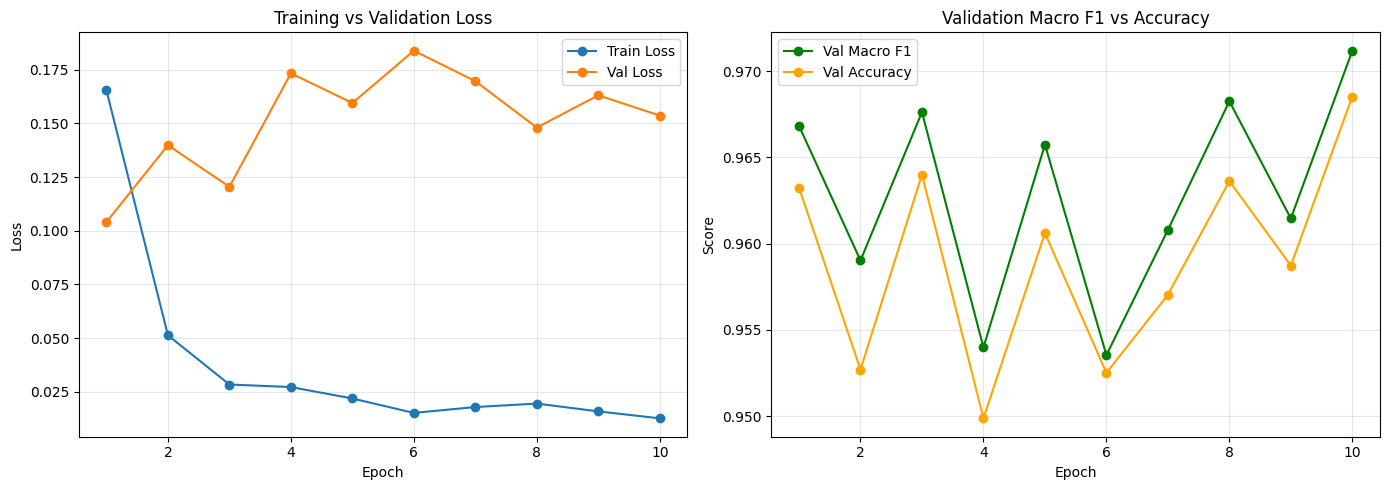

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Val Loss", marker="o")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], label="Val Macro F1", marker="o", color="green")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy", marker="o", color="orange")
axes[1].set_title("Validation Macro F1 vs Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Evaluasi Model Terbaik

Load kembali `best_convnext_tiny.pth` (berdasarkan Macro F1 terbaik), lalu evaluasi lengkap di validation set:
1. Macro F1 Score
2. Classification Report (precision, recall, f1-score per kelas)
3. Confusion Matrix — fokus analisis: apakah kelas **Electronic** sering salah diprediksi menjadi Recyclable/Organic.

In [ ]:
# Load model terbaik
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluasi Model Terbaik"):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

final_macro_f1 = f1_score(all_labels, all_preds, average="macro")

print("=" * 60)
print(f"FINAL VALIDATION MACRO F1 : {final_macro_f1:.4f}")
print("=" * 60)


Evaluasi Model Terbaik:   0%|          | 0/166 [00:00<?, ?it/s]

FINAL VALIDATION MACRO F1 : 0.9712


In [ ]:
report_text = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
)

print(report_text)

with open(CLASSIFICATION_REPORT_PATH, "w") as f:
    f.write("CONVNEXT TINY - CLASSIFICATION REPORT\n")
    f.write("=" * 60 + "\n")
    f.write(f"Validation Macro F1 : {final_macro_f1:.4f}\n")
    f.write("=" * 60 + "\n\n")
    f.write(report_text)

print(f"Classification report disimpan di: {CLASSIFICATION_REPORT_PATH}")


              precision    recall  f1-score   support

0_Recyclable     0.9540    0.9645    0.9592      2000
1_Electronic     0.9898    0.9760    0.9828       792
   2_Organic     0.9736    0.9694    0.9715      2514

    accuracy                         0.9685      5306
   macro avg     0.9725    0.9700    0.9712      5306
weighted avg     0.9686    0.9685    0.9686      5306

Classification report disimpan di: /content/drive/MyDrive/BDC2026/ConvNeXt_Result/classification_report.txt


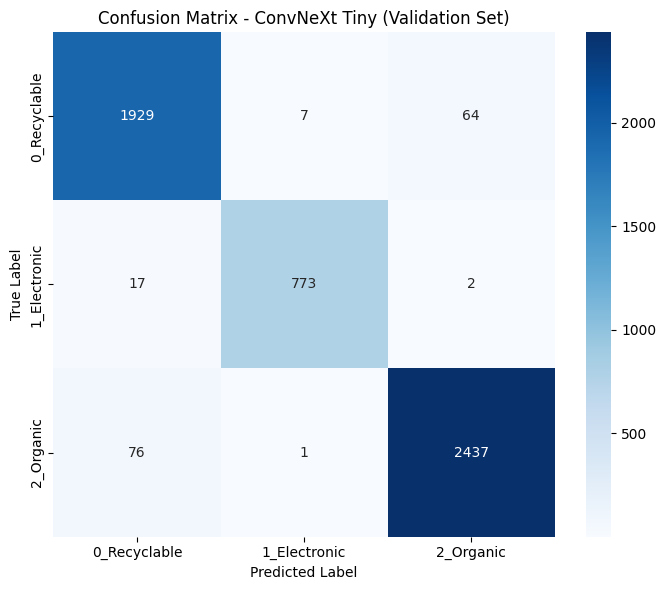

Confusion matrix disimpan di: /content/drive/MyDrive/BDC2026/ConvNeXt_Result/confusion_matrix.png


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - ConvNeXt Tiny (Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig(CONFUSION_MATRIX_PATH, dpi=200)
plt.show()

print(f"Confusion matrix disimpan di: {CONFUSION_MATRIX_PATH}")


In [ ]:
# ==========================================================
# Analisis kelas Electronic (kelas minoritas)
# ==========================================================

electronic_idx = class_names.index("1_Electronic") if "1_Electronic" in class_names else 1

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

electronic_row = cm_df.iloc[electronic_idx]
total_electronic = electronic_row.sum()

print("=" * 60)
print("ANALISIS KELAS ELECTRONIC")
print("=" * 60)
for cls_name, count in electronic_row.items():
    pct = (count / total_electronic) * 100 if total_electronic > 0 else 0
    print(f"Prediksi sebagai {cls_name:15}: {count:5} ({pct:5.2f}%)")
print("=" * 60)

if total_electronic > 0:
    correct_pct = (electronic_row[class_names[electronic_idx]] / total_electronic) * 100
    print(f"Kelas Electronic terklasifikasi benar sebesar {correct_pct:.2f}%.")
    print("Persentase sisanya menunjukkan salah klasifikasi ke Recyclable / Organic,")
    print("yang perlu diperhatikan mengingat Electronic adalah kelas minoritas.")


ANALISIS KELAS ELECTRONIC
Prediksi sebagai 0_Recyclable   :    17 ( 2.15%)
Prediksi sebagai 1_Electronic   :   773 (97.60%)
Prediksi sebagai 2_Organic      :     2 ( 0.25%)
Kelas Electronic terklasifikasi benar sebesar 97.60%.
Persentase sisanya menunjukkan salah klasifikasi ke Recyclable / Organic,
yang perlu diperhatikan mengingat Electronic adalah kelas minoritas.


## 11. Prediksi Test Set & Membuat Submission File

Menjalankan model terbaik pada `test_loader`, lalu menyimpan hasil prediksi ke `submission_convnext.csv`
dengan format `id,predicted` sesuai template BDC. Urutan mengikuti urutan `test_loader`
(sudah terurut berdasarkan nama file dari `pipeline_bdc.py`).

In [ ]:
all_filenames = []
all_test_preds = []

model.eval()

with torch.no_grad():
    for images, filenames in tqdm(test_loader, desc="Predicting Test Set"):

        images = images.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_filenames.extend(filenames)
        all_test_preds.extend(preds.cpu().numpy())

submission_df = pd.DataFrame({
    "id": all_filenames,
    "predicted": all_test_preds
})

print(f"Total prediksi test set : {len(submission_df)}")
submission_df.head()


Predicting Test Set:   0%|          | 0/46 [00:00<?, ?it/s]

Total prediksi test set : 1458


,id,predicted
0,1.jpg,2
1,10.jpg,2
2,100.jpg,0
3,1000.jpg,2
4,1001.jpg,0


In [ ]:
# ==========================================================
# Jika ada template submission resmi di SUBMISSION_DIR,
# urutkan hasil prediksi mengikuti urutan template tersebut.
# ==========================================================

template_candidates = [
    os.path.join(SUBMISSION_DIR, "sample_submission.csv"),
    os.path.join(SUBMISSION_DIR, "submission_template.csv"),
]

template_path = next((p for p in template_candidates if os.path.exists(p)), None)

if template_path is not None:
    template_df = pd.read_csv(template_path)
    id_col = template_df.columns[0]

    submission_df = (
        template_df[[id_col]]
        .rename(columns={id_col: "id"})
        .merge(submission_df, on="id", how="left")
    )

    print(f"Urutan submission disesuaikan dengan template: {template_path}")
else:
    print("Template submission tidak ditemukan, menggunakan urutan dari test_loader.")

submission_df.to_csv(SUBMISSION_PATH, index=False)

print(f"Submission disimpan di: {SUBMISSION_PATH}")
submission_df.head()


Template submission tidak ditemukan, menggunakan urutan dari test_loader.
Submission disimpan di: /content/drive/MyDrive/BDC2026/ConvNeXt_Result/submission_convnext.csv


,id,predicted
0,1.jpg,2
1,10.jpg,2
2,100.jpg,0
3,1000.jpg,2
4,1001.jpg,0


## 12. Ringkasan Akhir

In [ ]:
print("=" * 60)
print("CONVNEXT TINY - SELESAI")
print("=" * 60)
print(f"Best Validation Macro F1  : {final_macro_f1:.4f}")
print()
print("File yang dihasilkan di ConvNeXt_Result/:")
print(f"  - {os.path.basename(BEST_MODEL_PATH)}")
print(f"  - {os.path.basename(HISTORY_CSV_PATH)}")
print(f"  - {os.path.basename(CLASSIFICATION_REPORT_PATH)}")
print(f"  - {os.path.basename(CONFUSION_MATRIX_PATH)}")
print(f"  - {os.path.basename(SUBMISSION_PATH)}")
print("=" * 60)
print(f"Lokasi folder: {CONVNEXT_RESULT_DIR}")


CONVNEXT TINY - SELESAI
Best Validation Macro F1  : 0.9712

File yang dihasilkan di ConvNeXt_Result/:
  - best_convnext_tiny.pth
  - training_history.csv
  - classification_report.txt
  - confusion_matrix.png
  - submission_convnext.csv
Lokasi folder: /content/drive/MyDrive/BDC2026/ConvNeXt_Result
